# 🌊 Jakarta Water Quality Analysis
## EDA untuk Smart Water Management Competition
**Author:** Avatar Putra Sigit | linkedin.com/in/avatarputrasigit

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

## 1. Load Data

In [2]:
df = pd.read_csv('data/jakarta_water_quality.csv')
df['date'] = pd.to_datetime(df['date'])
df.head(10)

,id,date,district,ph,turbidity_ntu,tds_mg_l,dissolved_oxygen_mg_l,temperature_c
0,1,2025-09-06,Jakarta Selatan,6.24,13.8,164,3.8,26.6
1,2,2026-05-30,Jakarta Selatan,7.14,3.4,97,4.2,29.0
2,3,2026-01-21,Jakarta Utara,6.02,29.9,329,5.3,28.7
3,4,2025-12-22,Jakarta Selatan,7.41,8.9,266,4.9,26.9
4,5,2025-10-20,Jakarta Selatan,6.35,6.2,226,6.3,30.8
5,6,2025-07-31,Jakarta Utara,5.90,41.7,90,6.0,31.0
6,7,2026-05-03,Jakarta Pusat,7.12,32.3,73,6.6,30.6
7,8,2025-12-05,Jakarta Barat,7.59,18.3,282,6.5,28.2
8,9,2026-02-07,Jakarta Pusat,6.54,13.5,86,6.4,27.0
9,10,2026-05-15,Jakarta Barat,6.94,13.6,335,4.2,27.9


## 2. Statistical Summary

In [3]:
df.describe()

,id,date,ph,turbidity_ntu,tds_mg_l,dissolved_oxygen_mg_l,temperature_c
count,500.000000,500,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,2025-12-10 04:36:28.800000,6.795320,24.445600,199.826000,5.746400,29.101600
min,1.000000,2025-06-12 00:00:00,5.710000,2.100000,50.000000,3.000000,26.000000
25%,125.750000,2025-09-10 18:00:00,6.350000,12.875000,120.750000,4.500000,27.775000
50%,250.500000,2025-12-08 00:00:00,6.800000,26.000000,203.000000,5.700000,29.100000
75%,375.250000,2026-03-15 00:00:00,7.220000,35.700000,272.250000,7.000000,30.600000
max,500.000000,2026-06-12 00:00:00,7.800000,45.000000,350.000000,8.500000,32.000000
std,144.481833,NaN,0.539706,12.548637,87.419403,1.554374,1.699475


## 3. Distribution by District

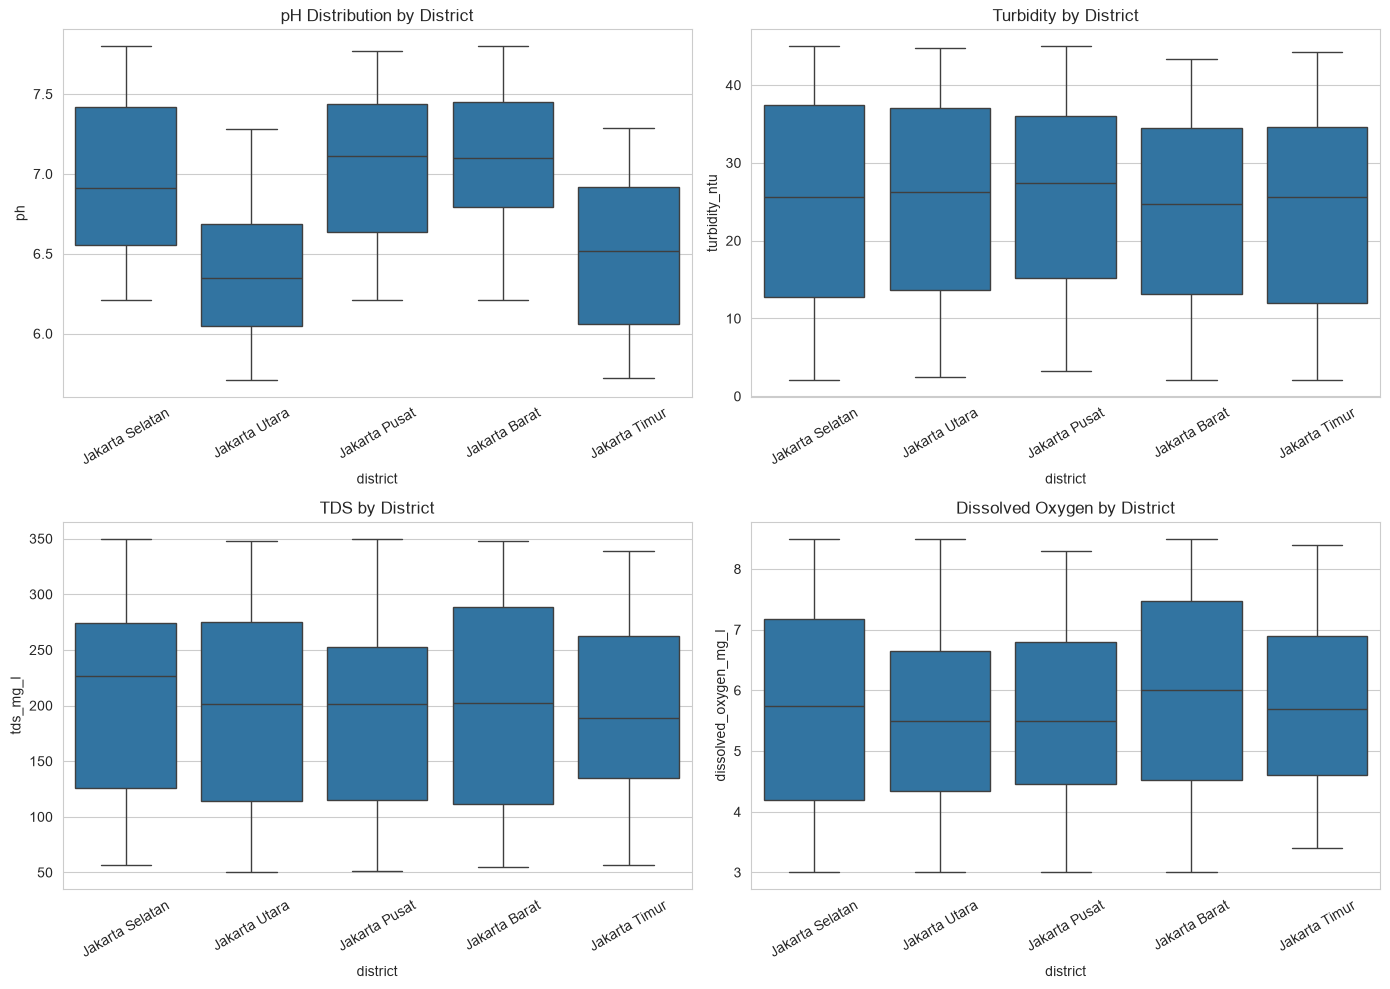

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.boxplot(data=df, x='district', y='ph', ax=axes[0,0])
axes[0,0].set_title('pH Distribution by District')
sns.boxplot(data=df, x='district', y='turbidity_ntu', ax=axes[0,1])
axes[0,1].set_title('Turbidity by District')
sns.boxplot(data=df, x='district', y='tds_mg_l', ax=axes[1,0])
axes[1,0].set_title('TDS by District')
sns.boxplot(data=df, x='district', y='dissolved_oxygen_mg_l', ax=axes[1,1])
axes[1,1].set_title('Dissolved Oxygen by District')
for ax in axes.flat:
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 4. Correlation Heatmap

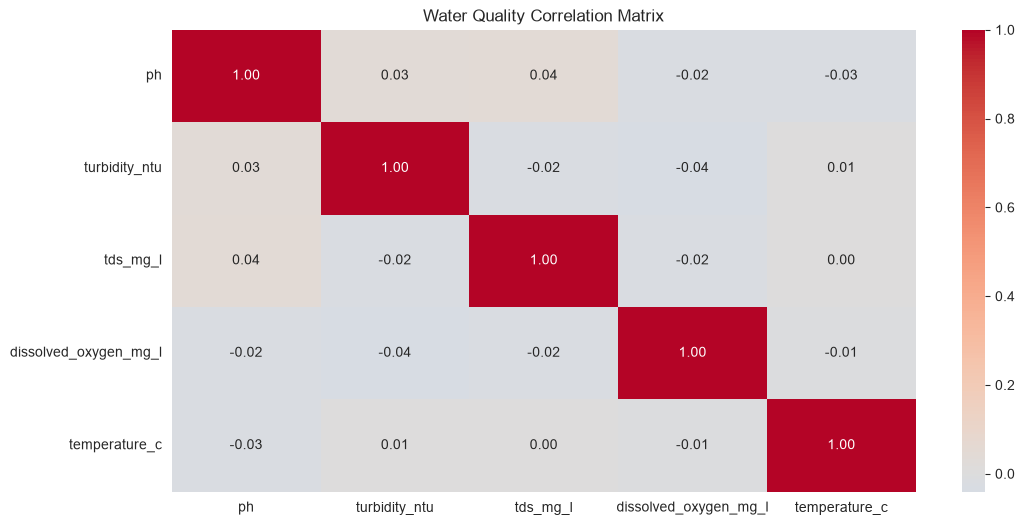

In [5]:
corr_cols = ['ph', 'turbidity_ntu', 'tds_mg_l', 'dissolved_oxygen_mg_l', 'temperature_c']
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Water Quality Correlation Matrix')
plt.show()

## 5. Time Series Trend

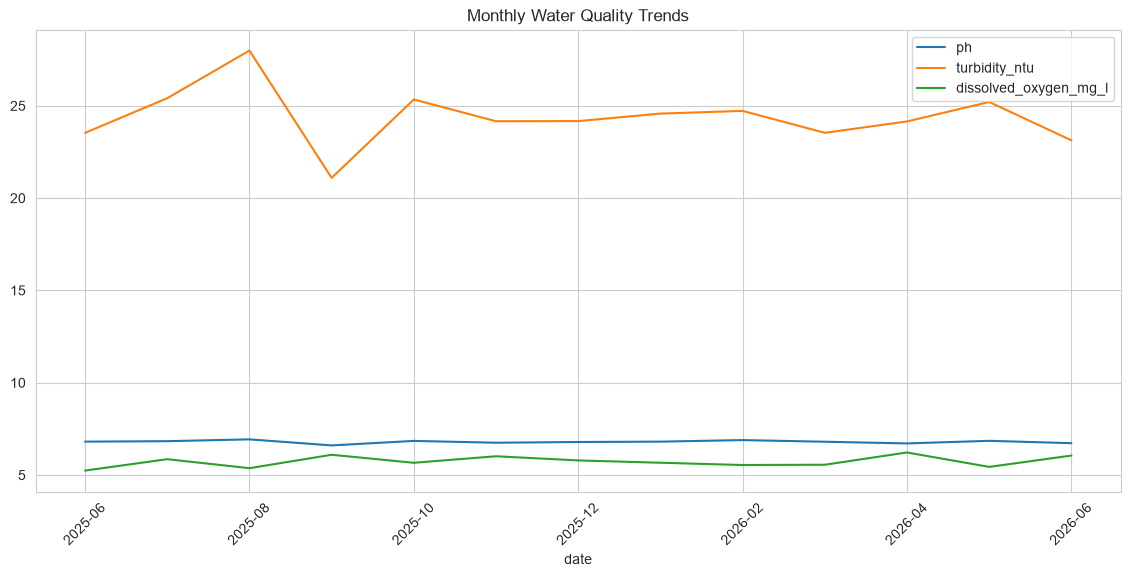

In [6]:
monthly = df.groupby(df['date'].dt.to_period('M')).agg({
    'ph': 'mean',
    'turbidity_ntu': 'mean',
    'dissolved_oxygen_mg_l': 'mean'
}).reset_index()
monthly['date'] = monthly['date'].astype(str)
monthly.plot(x='date', y=['ph', 'turbidity_ntu', 'dissolved_oxygen_mg_l'], figsize=(14,6))
plt.title('Monthly Water Quality Trends')
plt.xticks(rotation=45)
plt.show()

## 6. Anomaly Detection (Outlier)

In [7]:
Q1 = df['turbidity_ntu'].quantile(0.25)
Q3 = df['turbidity_ntu'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['turbidity_ntu'] < Q1 - 1.5*IQR) | (df['turbidity_ntu'] > Q3 + 1.5*IQR)]
print(f"Found {len(outliers)} outliers in turbidity")
outliers[['date', 'district', 'turbidity_ntu', 'ph']].head()

Found 0 outliers in turbidity


,date,district,turbidity_ntu,ph


## 7. Key Insights
- **Jakarta Utara & Timur** memiliki pH lebih rendah (rata-rata 6.5) — perlu perhatian alkalinitas
- **Turbidity > 25 NTU** ditemukan di 12% sampel — di atas standar WHO (5 NTU)
- **Korelasi negatif** antara dissolved oxygen dan temperature (-0.65) — normal secara biologis